In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Define the path to your AnnData file
# PLEASE UPDATE THIS PATH
adata_path_before = '/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/second_phase_combine/final_file_for_split_updated.h5ad' 

try:
    adata = sc.read_h5ad(adata_path_before)
    print("AnnData object loaded successfully.")
except FileNotFoundError:
    print(f"ERROR: The file was not found at '{adata_path_before}'.")
    print("Please update the 'adata_path_before' variable to the correct location of your h5ad file.")
    # In a real notebook, you might stop execution here.
    # We will create a dummy object to allow the script to continue for demonstration.
    #adata = sc.AnnData(np.random.rand(100, 200), obs={'cell_id': ['A549']*50 + ['MCF7']*50, 'dataset_name': ['GSE70138']*50 + ['GSE92742']*50, 'pert_type': ['trt_cp']*50 + ['ctl_vehicle']*50})


print("--- Dataset Overview ---")
print(f"Dimensions: {adata.n_obs} observations (samples) × {adata.n_vars} variables (genes)")
print("--- Observation Metadata (.obs) ---")
print("Available columns:", adata.obs.columns.tolist())
print(adata.obs.head())


AnnData object loaded successfully.
--- Dataset Overview ---
Dimensions: 1038163 observations (samples) × 978 variables (genes)
--- Observation Metadata (.obs) ---
Available columns: ['dataset_name', 'sig_id', 'pert_id', 'pert_iname', 'pert_type', 'cell_id', 'pert_idose', 'pert_itime', 'condition', 'canonical_smiles', 'valid_smiles', 'pert_dose', 'pert_dose_unit', 'inchi_key', 'chembl_id', 'mechanism_of_action', 'action_type', 'action_type_filtered', 'mechanism_of_action_filtered']
  dataset_name                 sig_id        pert_id      pert_iname  \
0     GSE70138  REP.A001_A375_24H:A03           DMSO            DMSO   
1     GSE70138  REP.A001_A375_24H:A04           DMSO            DMSO   
2     GSE70138  REP.A001_A375_24H:A05           DMSO            DMSO   
3     GSE70138  REP.A001_A375_24H:A06           DMSO            DMSO   
4     GSE70138  REP.A001_A375_24H:A07  BRD-K25114078  aminoguanidine   

     pert_type cell_id pert_idose pert_itime       condition canonical_smiles  \

In [86]:
adata.obs["pert_iname"].unique()


['DMSO', 'aminoguanidine', 'pritelivir', 'batimastat', 'CX-516', ..., 'BRD-K22321414', 'BRD-K21001652', 'PF-543', 'AVA', 'BRD-K64106162']
Length: 17936
Categories (17936, object): ['1,2,3,4,5,6-hexabromocyclohexane', '1,2,3,4-tetrahydroisoquinoline', '1,2-dichlorobenzene', '1,2-propylene-glycol', ..., 'zopiclone', 'zosuquidar', 'zoxazolamine', 'zuclopenthixol']

In [15]:
#Step 1 — Understand Metadata Composition
print("Total samples:", adata.n_obs)
print("\nCell lines:")
print(adata.obs['cell_id'].value_counts())

print("\nPerturbation types:")
print(adata.obs['pert_type'].value_counts())

print("\nDatasets:")
print(adata.obs['dataset_name'].value_counts())

print("\nPerturbation Time:")
print(adata.obs['pert_itime'].value_counts())

Total samples: 1038163

Cell lines:
cell_id
MCF7        145001
PC3         133548
VCAP        120941
A375         92403
HT29         90752
             ...  
COV644         689
T3M10          687
NCIH1694       670
SNUC5          651
HS27A           93
Name: count, Length: 82, dtype: int64

Perturbation types:
pert_type
trt_cp         964902
ctl_vehicle     73261
Name: count, dtype: int64

Datasets:
dataset_name
GSE92742    705344
GSE70138    332819
Name: count, dtype: int64

Perturbation Time:
pert_itime
24 h    684841
6 h     337821
3 h      15243
48 h       258
Name: count, dtype: int64


In [58]:
# # Filter cell lines with more than 50,000 samples
# cell_line_counts = adata.obs['cell_id'].value_counts()
# cell_lines_to_keep = cell_line_counts[cell_line_counts > 50000].index

# # Filter the data to keep only the selected cell lines
# adata_filtered = adata[adata.obs['cell_id'].isin(cell_lines_to_keep)]

# # Check the result
# print("Filtered Cell Lines with more than 50,000 samples:")
# print(adata_filtered.obs['cell_id'].value_counts())

Filtered Cell Lines with more than 50,000 samples:
cell_id
MCF7    145001
PC3     133548
VCAP    120941
A375     92403
HT29     90752
A549     70857
HA1E     68699
Name: count, dtype: int64


In [16]:
# -----------------------------
# Step 1: Define subset size
# -----------------------------
n_samples_for_viz = 100000
n_samples_for_viz = min(n_samples_for_viz, adata.n_obs)

print(f"Creating a subset of {n_samples_for_viz} samples...")

# -----------------------------
# Step 2: Stratified Subsetting by 'cell_id'
# -----------------------------

# Get integer positions of each cell_id
cell_counts = adata.obs['cell_id'].value_counts()
cell_proportions = cell_counts / cell_counts.sum()

# Determine number of samples per cell line
samples_per_cell = (cell_proportions * n_samples_for_viz).astype(int)

# Adjust to sum exactly to n_samples_for_viz
diff = n_samples_for_viz - samples_per_cell.sum()
if diff > 0:
    samples_per_cell.iloc[0] += diff

# Collect integer positions
subset_indices = []
for cell_line, n in samples_per_cell.items():
    # Get boolean mask for this cell line
    mask = adata.obs['cell_id'] == cell_line
    # Get integer positions (np.where returns positions)
    positions = np.where(mask)[0]
    # Randomly sample positions
    chosen = np.random.choice(positions, size=n, replace=False)
    subset_indices.extend(chosen)

# Create subset using integer positions
adata_subset_before = adata[subset_indices, :].copy()

print("Subset created.")
print(f"Subset size: {adata_subset_before.n_obs}")

# -----------------------------
# Step 3: Check distributions
# -----------------------------
print("\nCell line distribution in subset (top 20):")
print(adata_subset_before.obs['cell_id'].value_counts().head(20))

print("\nPerturbation types in subset:")
print(adata_subset_before.obs['pert_type'].value_counts())

print("\nPerturbation times in subset (top 20):")
if 'pert_itime' in adata_subset_before.obs.columns:
    print(adata_subset_before.obs['pert_itime'].value_counts().head(20))

Creating a subset of 100000 samples...
Subset created.
Subset size: 100000

Cell line distribution in subset (top 20):
cell_id
MCF7        14006
PC3         12863
VCAP        11649
A375         8900
HT29         8741
A549         6825
HA1E         6617
HCC515       3227
HELA         3008
YAPC         2980
HEPG2        2393
NPC          1772
ASC          1214
NEU          1207
BT20          951
SKBR3         947
MDAMB231      915
MCF10A        865
HS578T        846
SKB           766
Name: count, dtype: int64

Perturbation types in subset:
pert_type
trt_cp         92923
ctl_vehicle     7077
Name: count, dtype: int64

Perturbation times in subset (top 20):
pert_itime
24 h    66019
6 h     32508
3 h      1453
48 h       20
Name: count, dtype: int64


In [18]:
###########################################################
# Ensure PCA exists for subset befor batch correction
###########################################################

if 'pca' not in adata_subset_before.uns:
    print("PCA not found. Running PCA now...")
    sc.tl.pca(adata_subset_before, n_comps=50, svd_solver='arpack')

###########################################################
# Plot explained variance (PERCENTAGE + cumulative)
###########################################################

import numpy as np
import matplotlib.pyplot as plt

print("\n--- Plotting PCA Variance Ratio (Percentage) for subset befor batch correction ---")

# Extract variance ratio safely
var_ratio = adata_subset_before.uns['pca']['variance_ratio']
n_pcs = min(50, len(var_ratio))

# Convert to percentage
var_ratio_percent = var_ratio[:n_pcs] * 100

# Compute cumulative variance
cumulative = np.cumsum(var_ratio_percent)



# Plot
plt.figure(figsize=(10, 6), dpi=150)

plt.plot(range(1, n_pcs + 1), var_ratio_percent, marker='o', label='Individual')
plt.plot(range(1, n_pcs + 1), cumulative, linestyle='--', label='Cumulative')




plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('PCA Explained Variance befor Batch Correction')

plt.ylim(0, 100)
plt.xticks(range(1, n_pcs + 1, 5))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.savefig("PCA_variance_ratio_percent_befor.png", dpi=300, bbox_inches='tight')
plt.close()

print("PCA variance (percentage + cumulative) plot befor batch correction saved.")

PCA not found. Running PCA now...

--- Plotting PCA Variance Ratio (Percentage) for subset befor batch correction ---
PCA variance (percentage + cumulative) plot befor batch correction saved.


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

# Step 3: Data Scaling
print("--- Step 3: Scaling Data ---")

# Scale data for PCA
sc.pp.scale(adata_subset_before, max_value=10)


# Step 4: PCA
print("\n--- Step 4: Running PCA ---")

# Run PCA
sc.tl.pca(adata_subset_before, n_comps=50, svd_solver='arpack')

print("PCA calculation complete.")


###########################################################
# Plot explained variance
###########################################################

sc.pl.pca_variance_ratio(
    adata_subset_before,
    log=True,
    n_pcs=50,
    show=False
)

plt.savefig(
    "PCA_variance_ratio.png",
    dpi=300,
    bbox_inches='tight'
)

plt.close()


###########################################################
# PCA by Dataset
###########################################################

if 'dataset_name' in adata_subset_before.obs.columns:

    sc.pl.pca(
        adata_subset_before,
        color='dataset_name',
        title='PCA by Dataset',
        show=False,
        size=15,
        alpha=0.9
    )

    plt.title('PCA by Dataset', fontsize=16, weight='bold')
    plt.gca().tick_params(axis='both', labelsize=10)
    plt.gcf().set_size_inches(12, 10)

    plt.legend(
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        fontsize=12
    )

    plt.savefig(
        "PCA_by_Dataset.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()


###########################################################
# PCA by Top 20 Cell IDs ONLY
###########################################################

if 'cell_id' in adata_subset_before.obs.columns:

    print("\nSelecting Top 20 cell_id values...")

    top20_cellids = (
        adata_subset_before.obs['cell_id']
        .value_counts()
        .head(20)
        .index
    )

    # Work on copy (safe)
    adata_cell20 = adata_subset_before[
        adata_subset_before.obs['cell_id'].isin(top20_cellids)
    ].copy()

    print("Plotting PCA for Top 20 Cell IDs...")

    sc.pl.pca(
        adata_cell20,
        color='cell_id',
        title='PCA by Top 20 Cell Lines',
        show=False,
        size=15,
        alpha=0.9,
        palette=sns.color_palette("tab20", 20)
    )

    plt.title(
        'PCA by Top 20 Cell Lines',
        fontsize=16,
        weight='bold'
    )

    plt.gca().tick_params(axis='both', labelsize=10)

    plt.gcf().set_size_inches(12, 10)

    plt.legend(
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        fontsize=10
    )

    plt.savefig(
        "PCA_by_Top20_Cell_Line.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()


print("\nPCA plots saved successfully.")

--- Step 3: Scaling Data ---

--- Step 4: Running PCA ---
PCA calculation complete.

Selecting Top 20 cell_id values...
Plotting PCA for Top 20 Cell IDs...

PCA plots saved successfully.


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
import scanpy as sc
import pandas as pd

# Section 5: UMAP for Non-Linear Dimensionality Reduction

print("\n--- Section 5: UMAP Embedding with Clean Solid Dots ---")

############################################################
# Step 5a: Compute neighbor graph
############################################################

print("Calculating neighbor graph...")
sc.pp.neighbors(adata_subset_before, n_neighbors=15, n_pcs=50)
print("Neighbor graph complete.\n")


############################################################
# Step 5b: Run UMAP
############################################################

print("Running UMAP...")
sc.tl.umap(adata_subset_before)
print("UMAP calculation complete.\n")


############################################################
# Step 5c: Visualize UMAP
############################################################

# Solid dots instead of faint blur
alpha_val = 0.9

categorical_cols = ['dataset_name', 'cell_id', 'pert_type', 'pert_itime']


for col in categorical_cols:

    if col in adata_subset_before.obs.columns:

        print(f"\nProcessing column: {col}")

        # Work on copy (prevents shrinking dataset repeatedly)
        adata_plot = adata_subset_before.copy()

        n_cats = adata_plot.obs[col].nunique()

        ####################################################
        # Select top 20 categories where needed
        ####################################################

        if col in ['cell_id', 'pert_type', 'pert_itime']:

            top_20_values = (
                adata_plot.obs[col]
                .value_counts()
                .head(20)
                .index
            )

            adata_plot = adata_plot[
                adata_plot.obs[col].isin(top_20_values)
            ]

            print(f"Top 20 values selected for '{col}'.")


        ####################################################
        # Color palette
        ####################################################

        palette = (
            sns.color_palette("tab20", 20)
            if n_cats > 10
            else sns.color_palette("Set2", 10)
        )


        ####################################################
        # Plot UMAP (Example Style)
        ####################################################

        print(f"Plotting UMAP colored by '{col}'...")

        sc.pl.umap(
            adata_plot,
            color=col,
            title=f'UMAP by {col}',
            alpha=alpha_val,        # Solid clusters
            palette=palette,
            legend_loc='right',
            legend_fontsize=8,
            size=15,                # Small clean dots
            frameon=True,
            linewidth=0,            # Sharp circles
            show=False
        )


        ####################################################
        # Styling
        ####################################################

        plt.title(
            f'UMAP by {col}',
            fontsize=16,
            weight='bold'
        )

        plt.gca().tick_params(
            axis='both',
            labelsize=10
        )

        plt.gcf().set_size_inches(12, 10)


        ####################################################
        # Clean legend placement
        ####################################################

        plt.legend(
            loc='center left',
            bbox_to_anchor=(1, 0.5),
            fontsize=10,
            frameon=True
        )


        ####################################################
        # Save Figure
        ####################################################

        plt.savefig(
            f"UMAP_by_{col}.png",
            dpi=300,
            bbox_inches='tight'
        )

        plt.close()


print("\nAll UMAP plots saved successfully.")


--- Section 5: UMAP Embedding with Clean Solid Dots ---
Calculating neighbor graph...
Neighbor graph complete.

Running UMAP...


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


UMAP calculation complete.


Processing column: dataset_name
Plotting UMAP colored by 'dataset_name'...

Processing column: cell_id
Top 20 values selected for 'cell_id'.
Plotting UMAP colored by 'cell_id'...


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list



Processing column: pert_type
Top 20 values selected for 'pert_type'.
Plotting UMAP colored by 'pert_type'...


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list



Processing column: pert_itime
Top 20 values selected for 'pert_itime'.
Plotting UMAP colored by 'pert_itime'...


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list



All UMAP plots saved successfully.


In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

############################################################
# Filter µM doses and remove invalid values
############################################################

filtered_adata = adata_subset[
    (adata_subset.obs['pert_dose_unit'] == 'µM') &
    (~adata_subset.obs['pert_dose'].isin([-666, '%']))
].copy()


############################################################
# Keep Top 20 pert_dose values
############################################################

top20_doses = (
    filtered_adata.obs['pert_dose']
    .value_counts()
    .head(20)
    .index
)

filtered_adata = filtered_adata[
    filtered_adata.obs['pert_dose'].isin(top20_doses)
].copy()


############################################################
# Make categorical (removes colorbar)
############################################################

filtered_adata.obs['pert_dose'] = (
    filtered_adata.obs['pert_dose']
    .astype(str)
    .astype('category')
)


############################################################
# Compute neighbors + UMAP
############################################################

print("Calculating neighbor graph...")
sc.pp.neighbors(filtered_adata, n_neighbors=15, n_pcs=50)

print("Running UMAP...")
sc.tl.umap(filtered_adata)


############################################################
# Plot UMAP
############################################################

palette = sns.color_palette("tab20", 20)

sc.pl.umap(
    filtered_adata,
    color='pert_dose',
    palette=palette,
    alpha=0.9,
    size=15,
    frameon=True,
    linewidth=0,
    show=False
)


############################################################
# Styling
############################################################

plt.title(
    'UMAP by Top 20 pert_dose (µM)',
    fontsize=18,
    weight='bold'
)

plt.xlabel("UMAP1", fontsize=12)
plt.ylabel("UMAP2", fontsize=12)

plt.gcf().set_size_inches(14,10)


############################################################
# Move legend OUTSIDE
############################################################

ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()

plt.legend(
    handles,
    labels,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=10,
    frameon=True
)


############################################################
# Save figure
############################################################

plt.savefig(
    "UMAP_by_Top20_pert_dose_uM.png",
    dpi=300,
    bbox_inches='tight'
)

plt.close()

Calculating neighbor graph...
Running UMAP...


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [69]:
# # Filter the data to only keep 'pert_dose' values with 'pert_dose_unit' as 'µM'
# # and exclude 'pert_dose' values that are -666 or '%' (if applicable)
# filtered_adata = adata_subset[(adata_subset.obs['pert_dose_unit'] == 'µM') & 
#                               ~adata_subset.obs['pert_dose'].isin([-666, '%'])]

# # Check unique values after filtering to ensure no invalid data
# print("Unique values of pert_dose after filtering:", filtered_adata.obs['pert_dose'].unique())

# # Now proceed with UMAP embedding
# print("Calculating neighbor graph...")
# sc.pp.neighbors(filtered_adata, n_neighbors=15, n_pcs=50)
# print("Neighbor graph complete.")

# # Run UMAP
# print("Running UMAP...")
# sc.tl.umap(filtered_adata)
# print("UMAP calculation complete.")

# # Define the min and max for the color scale (based on data range or domain knowledge)
# pert_dose_min = filtered_adata.obs['pert_dose'].min()  # Minimum value
# pert_dose_max = filtered_adata.obs['pert_dose'].max()  # Maximum value

# # Plotting UMAP colored by pert_dose
# alpha_val = 0.05  # Transparency for dense points
# sc.pl.umap(filtered_adata,
#            color='pert_dose',
#            title='UMAP by pert_dose (µM)',
#            alpha=alpha_val,
#            vmin=pert_dose_min,  # Set minimum value for color scale
#            vmax=pert_dose_max,  # Set maximum value for color scale
#            show=False)  # Don't show interactively, to allow for customization

# # Customize plot
# plt.title('UMAP by pert_dose (µM)', fontsize=16, weight='bold')
# plt.gca().tick_params(axis='both', labelsize=10)  # Minimize font size for ticks
# plt.gcf().set_size_inches(12, 10)  # Increase figure size

# # Save high-resolution UMAP plot
# plt.savefig("UMAP_by_pert_dose_in_µM.png", dpi=300, bbox_inches='tight')
# plt.close()  # Close the plot after saving

Unique values of pert_dose after filtering: [1.000e+01 1.000e+00 5.000e-01 1.000e-01 5.000e+00 1.200e-01 3.330e+00
 3.000e+00 1.000e-02 3.700e-01 4.000e-02 2.000e+01 1.110e+00 1.000e+02
 1.000e-03 8.000e+01 5.000e+01 9.580e+00 9.000e+01 3.000e+01 4.000e+01
 4.170e+00 3.700e+00 3.360e+00 3.300e-01 2.000e+00 5.770e+00 1.005e+01
 3.850e+00 3.570e+00 1.111e+01 1.280e+00 3.333e+01 7.000e+01 6.400e-01
 7.500e-01 4.100e-01 2.100e-01 2.260e+00 2.500e-01 1.100e-01 6.000e+00
 6.000e+01 4.520e+00 4.000e-01 1.230e+00 1.072e+01 1.120e+00 3.730e+00
 3.000e-02 6.790e+00 2.200e-01 3.000e-01 1.920e+00 1.120e+01 1.300e-01
 1.190e+00 1.800e-01 1.060e+00 5.000e-02 8.000e-02 1.400e-01 3.350e+00
 3.500e+00 6.000e-02 1.200e+01 4.800e+00 2.700e+00 1.700e-01 2.500e+01
 4.000e+00 9.000e-01 5.500e+00 3.190e+00 4.500e+00 1.700e+00 2.000e-02
 8.110e+00 8.000e+00 6.700e-01 1.240e+00 1.510e+00 7.000e-02 1.390e+00
 1.500e-01 5.300e-01 3.500e-01]
Calculating neighbor graph...
Neighbor graph complete.
Running UMAP...


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


UMAP calculation complete.


after_ComBat

In [9]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os   

# -----------------------------
# Step 0: Define path to ComBat folds
# -----------------------------
combat_path = '/sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/split/splits_with_combat_both'

# List all files ending with "_train_combat.h5ad"
train_files = sorted([f for f in os.listdir(combat_path) if f.endswith('_train_combat_both.h5ad')])
test_files  = sorted([f for f in os.listdir(combat_path) if f.endswith('_test_combat_both.h5ad')])

# Pick fold 0 for visualization
train_file = os.path.join(combat_path, train_files[0])
test_file  = os.path.join(combat_path, test_files[0])

print(f"Using train: {train_file}")
print(f"Using test : {test_file}")

# -----------------------------
# Step 1: Load the fold
# -----------------------------
train = sc.read_h5ad(train_file)
test = sc.read_h5ad(test_file)

# Combine train + test
adata_viz = train.concatenate(
    test,
    batch_key="split",
    batch_categories=["train", "test"]
)

print(f"Combined dataset: {adata_viz.n_obs} cells x {adata_viz.n_vars} genes")

Using train: /sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/split/splits_with_combat_both/fold_0_train_combat_both.h5ad
Using test : /sybig/home/shs/projects/project1_L1000/datasets/lincs/merge/split/splits_with_combat_both/fold_0_test_combat_both.h5ad


/tmp/ipykernel_1458214/1957305435.py:30: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_viz = train.concatenate(


Combined dataset: 1033721 cells x 978 genes


In [10]:
# -----------------------------
# Step 2: Subset for visualization (optional)
# -----------------------------
n_samples_for_viz = 100000
n_samples_for_viz = min(n_samples_for_viz, adata_viz.n_obs)
print(f"Creating a subset of {n_samples_for_viz} samples...")

# Set random seed for reproducibility
np.random.seed(42)

# -----------------------------
# Step 2a: Stratified subsetting by 'cell_id'
# -----------------------------
cell_counts = adata_viz.obs['cell_id'].value_counts()
cell_proportions = cell_counts / cell_counts.sum()

# Determine how many cells per cell line
samples_per_cell = (cell_proportions * n_samples_for_viz).astype(int)

# Adjust to make the sum exactly n_samples_for_viz
diff = n_samples_for_viz - samples_per_cell.sum()
if diff > 0:
    samples_per_cell.iloc[0] += diff

subset_indices = []
for cell_line, n in samples_per_cell.items():
    mask = adata_viz.obs['cell_id'] == cell_line
    positions = np.where(mask)[0]
    # Ensure we don't sample more than available
    chosen = np.random.choice(positions, size=min(n, len(positions)), replace=False)
    subset_indices.extend(chosen)

# Create the subset
adata_subset_after = adata_viz[subset_indices, :].copy()

print("Subset created successfully.")
print(f"Subset size: {adata_subset_after.n_obs} cells")

# -----------------------------
# Step 3: Check distributions
# -----------------------------
print("\nCell line distribution in subset (top 20):")
print(adata_subset_after.obs['cell_id'].value_counts().head(20))

print("\nPerturbation types in subset:")
print(adata_subset_after.obs['pert_type'].value_counts())

if 'pert_itime' in adata_subset_after.obs.columns:
    print("\nPerturbation times in subset (top 20):")
    print(adata_subset_after.obs['pert_itime'].value_counts().head(20))

Creating a subset of 100000 samples...
Subset created successfully.
Subset size: 100000 cells

Cell line distribution in subset (top 20):
cell_id
MCF7        14055
PC3         12907
VCAP        11680
A375         8926
HT29         8771
A549         6835
HA1E         6635
HCC515       3223
HELA         3009
YAPC         2980
HEPG2        2393
NPC          1761
ASC          1203
NEU          1196
BT20          942
SKBR3         938
MDAMB231      907
MCF10A        857
HS578T        838
SKB           766
Name: count, dtype: int64

Perturbation types in subset:
pert_type
trt_cp         92869
ctl_vehicle     7131
Name: count, dtype: int64

Perturbation times in subset (top 20):
pert_itime
24 h    65819
6 h     32718
3 h      1434
48 h       29
Name: count, dtype: int64


In [11]:
###########################################################
# Ensure PCA exists for subset after batch correction
###########################################################

if 'pca' not in adata_subset_after.uns:
    print("PCA not found. Running PCA now...")
    sc.tl.pca(adata_subset_after, n_comps=50, svd_solver='arpack')

###########################################################
# Plot explained variance (PERCENTAGE + cumulative)
###########################################################

import numpy as np
import matplotlib.pyplot as plt

print("\n--- Plotting PCA Variance Ratio (Percentage) for subset after batch correction ---")

# Extract variance ratio safely
var_ratio = adata_subset_after.uns['pca']['variance_ratio']
n_pcs = min(50, len(var_ratio))

# Convert to percentage
var_ratio_percent = var_ratio[:n_pcs] * 100

# Compute cumulative variance
cumulative = np.cumsum(var_ratio_percent)



# Plot
plt.figure(figsize=(10, 6), dpi=150)

plt.plot(range(1, n_pcs + 1), var_ratio_percent, marker='o', label='Individual')
plt.plot(range(1, n_pcs + 1), cumulative, linestyle='--', label='Cumulative')

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('PCA Explained Variance after Batch Correction')

plt.ylim(0, 100)
plt.xticks(range(1, n_pcs + 1, 5))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.savefig("PCA_variance_ratio_percent_after.png", dpi=300, bbox_inches='tight')
plt.close()

print("PCA variance (percentage + cumulative) plot AFTER batch correction saved.")

PCA not found. Running PCA now...

--- Plotting PCA Variance Ratio (Percentage) for subset after batch correction ---
PCA variance (percentage + cumulative) plot AFTER batch correction saved.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

# -----------------------------
# Step 3: Scale data
# -----------------------------
print("--- Step 3: Scaling Data ---")
sc.pp.scale(adata_subset_after, max_value=10)
print("Data scaling complete.")

# -----------------------------
# Step 4: PCA
# -----------------------------
print("\n--- Step 4: Running PCA ---")
sc.tl.pca(adata_subset_after, n_comps=50, svd_solver='arpack')
print("PCA calculation complete.")

# -----------------------------
# Step 4a: Explained variance
# -----------------------------
sc.pl.pca_variance_ratio(
    adata_subset_after,
    log=True,
    n_pcs=50,
    show=False
)
plt.savefig("PCA_variance_ratio.png", dpi=300, bbox_inches='tight')
plt.close()
print("PCA variance ratio plot saved.")

# -----------------------------
# Step 4b: PCA for categorical columns
# -----------------------------
categorical_cols = ['dataset_name', 'cell_id', 'pert_type', 'pert_itime']

for col in categorical_cols:
    if col in adata_subset_after.obs.columns:
        adata_plot = adata_subset_after.copy()
        n_cats = adata_plot.obs[col].nunique()

        # For cell_id, pert_type, pert_itime → take top 20 categories for clarity
        if col in ['cell_id', 'pert_type', 'pert_itime']:
            top20_values = adata_plot.obs[col].value_counts().head(20).index
            adata_plot = adata_plot[adata_plot.obs[col].isin(top20_values)]

        palette = sns.color_palette("tab20", 20) if n_cats > 10 else sns.color_palette("Set2", 10)

        sc.pl.pca(
            adata_plot,
            color=col,
            title=f'PCA by {col}',
            show=False,
            size=15,
            alpha=0.9,
            palette=palette
        )

        plt.gcf().set_size_inches(12, 10)
        plt.gca().tick_params(axis='both', labelsize=10)
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
        plt.savefig(f"PCA_by_{col}.png", dpi=300, bbox_inches='tight')
        plt.close()
        print(f"PCA by {col} saved.")

print("\nAll PCA plots (dataset_name, cell_id, pert_type, pert_itime) saved successfully.")

--- Step 3: Scaling Data ---
Data scaling complete.

--- Step 4: Running PCA ---
PCA calculation complete.
PCA variance ratio plot saved.
PCA by dataset_name saved.


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


PCA by cell_id saved.


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


PCA by pert_type saved.


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


PCA by pert_itime saved.

All PCA plots (dataset_name, cell_id, pert_type, pert_itime) saved successfully.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import numpy as np

# -----------------------------
# Step 5: UMAP Embedding
# -----------------------------
print("\n--- Step 5: UMAP Embedding with Clean Solid Dots ---")

# Step 5a: Compute neighbor graph
print("Calculating neighbor graph...")
sc.pp.neighbors(adata_subset_after, n_neighbors=15, n_pcs=50)
print("Neighbor graph complete.\n")

# Step 5b: Run UMAP
print("Running UMAP...")
sc.tl.umap(adata_subset_after)
print("UMAP calculation complete.\n")

# Step 5c: Visualize UMAP
alpha_val = 0.9
categorical_cols = ['dataset_name', 'cell_id', 'pert_type', 'pert_itime']

for col in categorical_cols:
    if col in adata_subset_after.obs.columns:
        print(f"\nProcessing column: {col}")

        # Make a copy to avoid modifying original subset
        adata_plot = adata_subset_after.copy()
        n_cats = adata_plot.obs[col].nunique()

        # For cell_id, pert_type, pert_itime → take top 20 categories
        if col in ['cell_id', 'pert_type', 'pert_itime']:
            top20_values = adata_plot.obs[col].value_counts().head(20).index
            adata_plot = adata_plot[adata_plot.obs[col].isin(top20_values)]
            print(f"Top 20 values selected for '{col}'.")

        # Define color palette
        palette = sns.color_palette("tab20", 20) if n_cats > 10 else sns.color_palette("Set2", 10)

        # Plot UMAP
        sc.pl.umap(
            adata_plot,
            color=col,
            title=f'UMAP by {col}',
            alpha=alpha_val,
            palette=palette,
            legend_loc='right',
            legend_fontsize=8,
            size=15,
            frameon=True,
            linewidth=0,
            show=False
        )

        # Styling
        plt.title(f'UMAP by {col}', fontsize=16, weight='bold')
        plt.gca().tick_params(axis='both', labelsize=10)
        plt.gcf().set_size_inches(12, 10)
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, frameon=True)

        # Save figure
        plt.savefig(f"UMAP_by_{col}.png", dpi=300, bbox_inches='tight')
        plt.close()
        print(f"UMAP by {col} saved.")

print("\nAll UMAP plots saved successfully.")


--- Step 5: UMAP Embedding with Clean Solid Dots ---
Calculating neighbor graph...
Neighbor graph complete.

Running UMAP...


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


UMAP calculation complete.


Processing column: dataset_name
UMAP by dataset_name saved.

Processing column: cell_id
Top 20 values selected for 'cell_id'.


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


UMAP by cell_id saved.

Processing column: pert_type
Top 20 values selected for 'pert_type'.


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


UMAP by pert_type saved.

Processing column: pert_itime
Top 20 values selected for 'pert_itime'.


/sybig/home/shs/miniconda3/envs/project_1_L1000/lib/python3.14/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


UMAP by pert_itime saved.

All UMAP plots saved successfully.


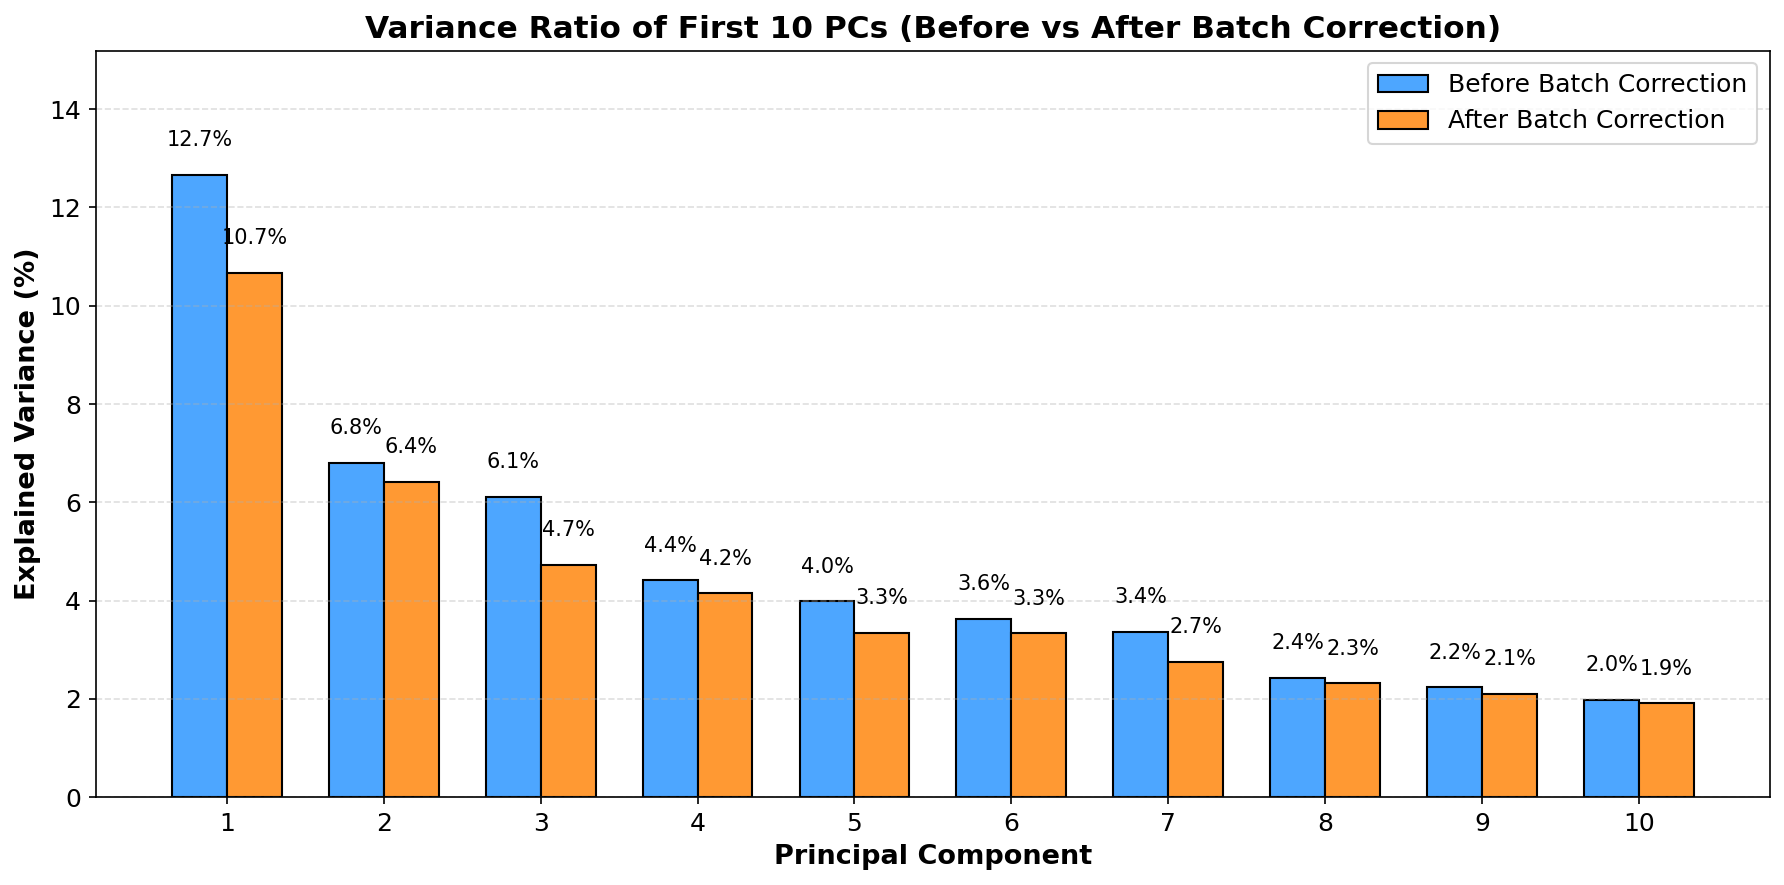

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Extract first 10 PCs
# -----------------------------
var_before = adata_subset_before.uns['pca']['variance_ratio'][:10] * 100  # %
var_after = adata_subset_after.uns['pca']['variance_ratio'][:10] * 100    # %

pcs = np.arange(1, 11)  # PC1 to PC10
width = 0.35

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6), dpi=150)

# Bars
bars_before = plt.bar(pcs - width/2, var_before, width=width, label='Before Batch Correction', color='#4da6ff', edgecolor='black')
bars_after = plt.bar(pcs + width/2, var_after, width=width, label='After Batch Correction', color='#ff9933', edgecolor='black')

# Add values on top of bars
for i in range(10):
    plt.text(pcs[i] - width/2, var_before[i] + 0.5, f'{var_before[i]:.1f}%', ha='center', va='bottom', fontsize=10)
    plt.text(pcs[i] + width/2, var_after[i] + 0.5, f'{var_after[i]:.1f}%', ha='center', va='bottom', fontsize=10)

# Labels and title
plt.xlabel('Principal Component', fontsize=13, weight='bold')
plt.ylabel('Explained Variance (%)', fontsize=13, weight='bold')
plt.title('Variance Ratio of First 10 PCs (Before vs After Batch Correction)', fontsize=15, weight='bold')

# Ticks and grid
plt.xticks(pcs, fontsize=12)
plt.ylim(0, max(max(var_before), max(var_after)) * 1.2)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Legend
plt.legend(fontsize=12, frameon=True)

plt.tight_layout()
plt.savefig("PC1_10_variance_comparison_clean.png", dpi=300)
plt.show()

In [22]:
import numpy as np

# Get cell lines from the BEFORE batch object, per dataset
celllines_dataset1 = adata_subset_before.obs.loc[
    adata_subset_before.obs['dataset_name'] == 'GSE70138', 'cell_id'
].unique()

celllines_dataset2 = adata_subset_before.obs.loc[
    adata_subset_before.obs['dataset_name'] == 'GSE92742', 'cell_id'
].unique()

# Shared cell lines
shared_celllines = np.intersect1d(celllines_dataset1, celllines_dataset2)
print("Shared cell lines:", shared_celllines)

# Top 3 frequent in before batch object
top3_shared = adata_subset_before.obs['cell_id'].value_counts().loc[shared_celllines].head(3).index.tolist()
print("Top 3 shared cell lines:", top3_shared)

# Filter both objects for these top 3 cell lines
adata_before_shared = adata_subset_before[adata_subset_before.obs['cell_id'].isin(top3_shared)].copy()
adata_after_shared = adata_subset_after[adata_subset_after.obs['cell_id'].isin(top3_shared)].copy()

Shared cell lines: ['A375' 'A549' 'ASC' 'BT20' 'CD34' 'HA1E' 'HCC515' 'HEPG2' 'HS578T' 'HT29'
 'JURKAT' 'MCF10A' 'MCF7' 'MDAMB231' 'NEU' 'NPC' 'PC3' 'SKBR3']
Top 3 shared cell lines: ['A375', 'A549', 'ASC']


In [21]:
# Dataset split
d1 = 'GSE70138'
d2 = 'GSE92742'

celllines_d1 = adata_ctl_before.obs.loc[
    adata_ctl_before.obs['dataset_name'] == d1, 'cell_id'
].unique()

celllines_d2 = adata_ctl_before.obs.loc[
    adata_ctl_before.obs['dataset_name'] == d2, 'cell_id'
].unique()

shared_celllines = np.intersect1d(celllines_d1, celllines_d2)
print("Shared cell lines:", shared_celllines)

Shared cell lines: ['A375' 'A549' 'ASC' 'BT20' 'CD34' 'HA1E' 'HCC515' 'HEPG2' 'HS578T' 'HT29'
 'JURKAT' 'MCF10A' 'MCF7' 'MDAMB231' 'NEU' 'NPC' 'PC3' 'SKBR3']


Shared cell lines: ['A375' 'A549' 'ASC' 'BT20' 'CD34' 'HA1E' 'HCC515' 'HEPG2' 'HS578T' 'HT29'
 'JURKAT' 'MCF10A' 'MCF7' 'MDAMB231' 'NEU' 'NPC' 'PC3' 'SKBR3']
Top 3 shared cell lines: ['A375', 'A549', 'ASC']


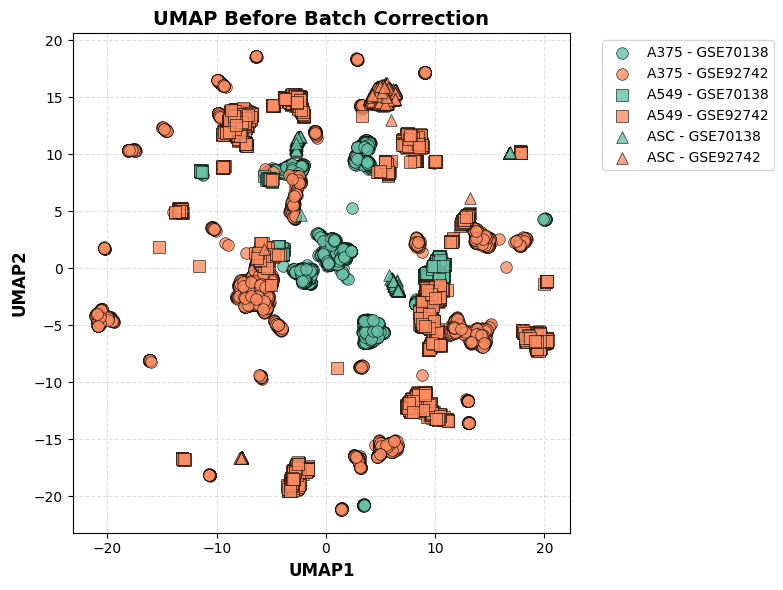

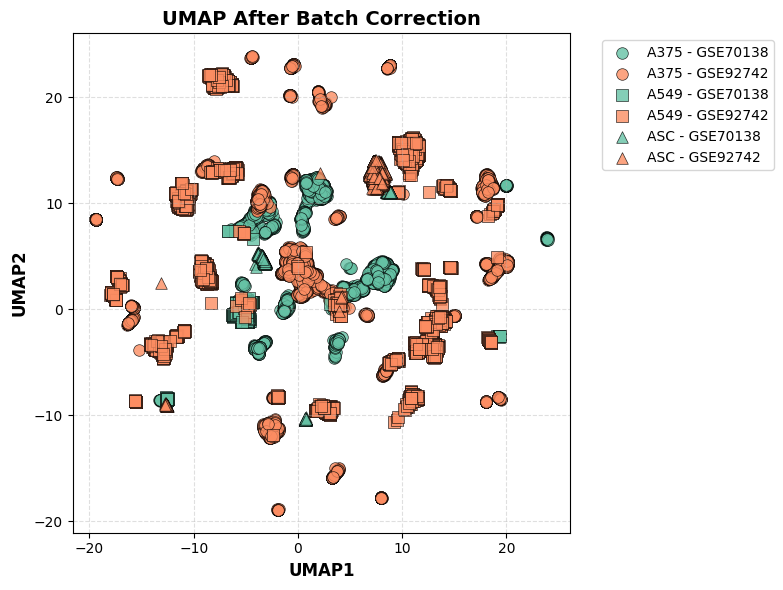

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# -----------------------------
# Step 1: Identify top 3 shared cell lines
# -----------------------------
celllines_dataset1 = adata_subset_before.obs.loc[
    adata_subset_before.obs['dataset_name'] == 'GSE70138', 'cell_id'
].unique()
celllines_dataset2 = adata_subset_before.obs.loc[
    adata_subset_before.obs['dataset_name'] == 'GSE92742', 'cell_id'
].unique()

shared_celllines = np.intersect1d(celllines_dataset1, celllines_dataset2)
print("Shared cell lines:", shared_celllines)

top3_shared = adata_subset_before.obs['cell_id'].value_counts().loc[shared_celllines].head(3).index.tolist()
print("Top 3 shared cell lines:", top3_shared)

# -----------------------------
# Step 2: Filter datasets (before and after)
# -----------------------------
adata_before_shared = adata_subset_before[adata_subset_before.obs['cell_id'].isin(top3_shared)].copy()
adata_after_shared = adata_subset_after[adata_subset_after.obs['cell_id'].isin(top3_shared)].copy()

# -----------------------------
# Step 3: Prepare plotting DataFrame
# -----------------------------
def prepare_df(adata, umap=True):
    df = adata.obs.copy()
    if umap:
        df['x'] = adata.obsm['X_umap'][:,0]
        df['y'] = adata.obsm['X_umap'][:,1]
    else:
        df['x'] = adata.obsm['X_pca'][:,0]
        df['y'] = adata.obsm['X_pca'][:,1]
    return df

df_before = prepare_df(adata_before_shared, umap=True)
df_after = prepare_df(adata_after_shared, umap=True)

# -----------------------------
# Step 4: Plotting function
# -----------------------------
def scatter_shared(df, title="UMAP Scatter", savefile=None):
    cell_lines = sorted(df['cell_id'].unique())
    datasets = sorted(df['dataset_name'].unique())
    
    markers = ['o','s','^']  # one per cell line
    marker_dict = dict(zip(cell_lines, markers))
    
    palette = sns.color_palette("Set2", n_colors=len(datasets))
    color_dict = dict(zip(datasets, palette))
    
    plt.figure(figsize=(8,6))
    
    for cell_line in cell_lines:
        df_sub = df[df['cell_id']==cell_line]
        for dataset in datasets:
            df_sub2 = df_sub[df_sub['dataset_name']==dataset]
            plt.scatter(
                df_sub2['x'],
                df_sub2['y'],
                s=70,
                alpha=0.8,
                marker=marker_dict[cell_line],
                color=color_dict[dataset],
                edgecolor='k',
                linewidth=0.5,
                label=f'{cell_line} - {dataset}'
            )
    
    plt.xlabel('UMAP1', fontsize=12, weight='bold')
    plt.ylabel('UMAP2', fontsize=12, weight='bold')
    plt.title(title, fontsize=14, weight='bold')
    plt.grid(True, linestyle='--', alpha=0.4)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05,1), loc='upper left', fontsize=10)
    
    plt.tight_layout()
    if savefile:
        plt.savefig(savefile, dpi=300, bbox_inches='tight')
    plt.show()

# -----------------------------
# Step 5: Plot before batch correction
# -----------------------------
scatter_shared(df_before, title="UMAP Before Batch Correction", savefile="UMAP_before_batch.png")

# -----------------------------
# Step 6: Plot after batch correction
# -----------------------------
scatter_shared(df_after, title="UMAP After Batch Correction", savefile="UMAP_after_batch.png")

Shared cell lines: ['A375' 'A549' 'ASC' 'BT20' 'CD34' 'HA1E' 'HCC515' 'HEPG2' 'HS578T' 'HT29'
 'JURKAT' 'MCF10A' 'MCF7' 'MDAMB231' 'NEU' 'NPC' 'PC3' 'SKBR3']
New top 3 shared cell lines: ['A549', 'ASC', 'BT20']


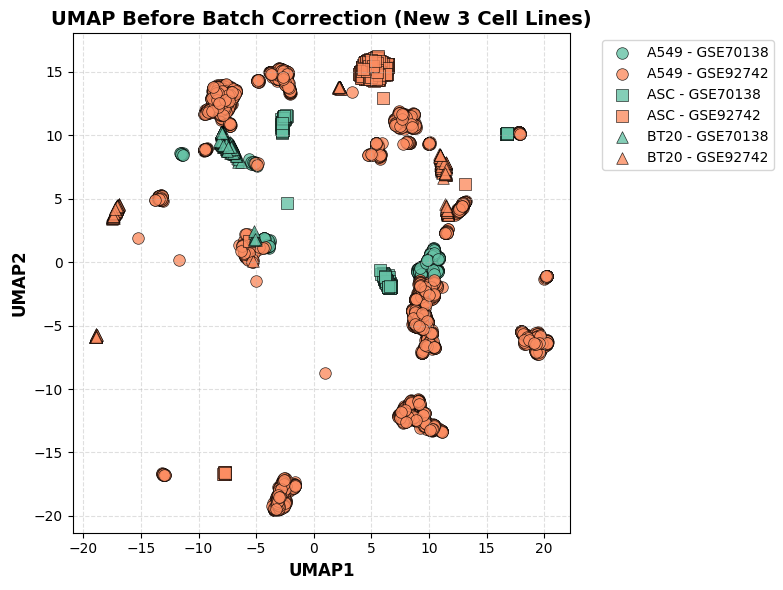

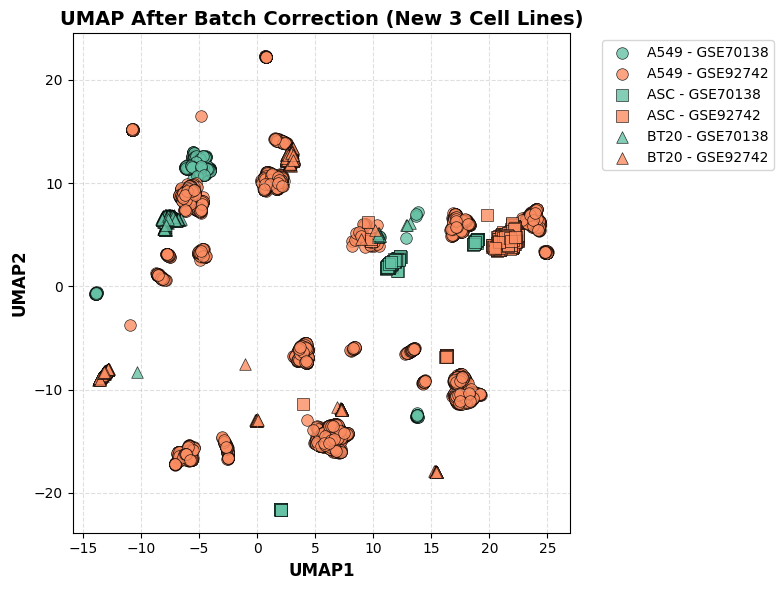

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd

# -----------------------------
# Step 1: Identify shared cell lines
# -----------------------------
celllines_dataset1 = adata_subset_before.obs.loc[
    adata_subset_before.obs['dataset_name'] == 'GSE70138', 'cell_id'
].unique()
celllines_dataset2 = adata_subset_before.obs.loc[
    adata_subset_before.obs['dataset_name'] == 'GSE92742', 'cell_id'
].unique()

shared_celllines = np.intersect1d(celllines_dataset1, celllines_dataset2)
print("Shared cell lines:", shared_celllines)

# -----------------------------
# Step 2: Pick a new set of 3 shared cell lines
# Example: pick 2nd, 3rd, 4th most frequent (change as needed)
# -----------------------------
shared_counts = adata_subset_before.obs['cell_id'].value_counts().loc[shared_celllines]
new_top3_shared = shared_counts.iloc[1:4].index.tolist()
print("New top 3 shared cell lines:", new_top3_shared)

# -----------------------------
# Step 3: Filter before and after datasets
# -----------------------------
adata_before_shared = adata_subset_before[adata_subset_before.obs['cell_id'].isin(new_top3_shared)].copy()
adata_after_shared = adata_subset_after[adata_subset_after.obs['cell_id'].isin(new_top3_shared)].copy()

# -----------------------------
# Step 4: Prepare DataFrame for plotting
# -----------------------------
def prepare_df(adata, umap=True):
    df = adata.obs.copy()
    if umap:
        df['x'] = adata.obsm['X_umap'][:,0]
        df['y'] = adata.obsm['X_umap'][:,1]
    else:
        df['x'] = adata.obsm['X_pca'][:,0]
        df['y'] = adata.obsm['X_pca'][:,1]
    return df

df_before = prepare_df(adata_before_shared, umap=True)
df_after = prepare_df(adata_after_shared, umap=True)

# -----------------------------
# Step 5: Plotting function
# -----------------------------
def scatter_shared(df, title="UMAP Scatter", savefile=None):
    cell_lines = sorted(df['cell_id'].unique())
    datasets = sorted(df['dataset_name'].unique())
    
    markers = ['o','s','^']  # one per cell line
    marker_dict = dict(zip(cell_lines, markers))
    
    palette = sns.color_palette("Set2", n_colors=len(datasets))
    color_dict = dict(zip(datasets, palette))
    
    plt.figure(figsize=(8,6))
    
    for cell_line in cell_lines:
        df_sub = df[df['cell_id']==cell_line]
        for dataset in datasets:
            df_sub2 = df_sub[df_sub['dataset_name']==dataset]
            plt.scatter(
                df_sub2['x'],
                df_sub2['y'],
                s=70,
                alpha=0.8,
                marker=marker_dict[cell_line],
                color=color_dict[dataset],
                edgecolor='k',
                linewidth=0.5,
                label=f'{cell_line} - {dataset}'
            )
    
    plt.xlabel('UMAP1', fontsize=12, weight='bold')
    plt.ylabel('UMAP2', fontsize=12, weight='bold')
    plt.title(title, fontsize=14, weight='bold')
    plt.grid(True, linestyle='--', alpha=0.4)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05,1), loc='upper left', fontsize=10)
    
    plt.tight_layout()
    if savefile:
        plt.savefig(savefile, dpi=300, bbox_inches='tight')
    plt.show()

# -----------------------------
# Step 6: Plot before batch correction
# -----------------------------
scatter_shared(df_before, title="UMAP Before Batch Correction (New 3 Cell Lines)", savefile="UMAP_before_batch_new3.png")

# -----------------------------
# Step 7: Plot after batch correction
# -----------------------------
scatter_shared(df_after, title="UMAP After Batch Correction (New 3 Cell Lines)", savefile="UMAP_after_batch_new3.png")

Shared cell lines: ['A375' 'A549' 'ASC' 'BT20' 'CD34' 'HA1E' 'HCC515' 'HEPG2' 'HS578T' 'HT29'
 'JURKAT' 'MCF10A' 'MCF7' 'MDAMB231' 'NEU' 'NPC' 'PC3' 'SKBR3']
Top 3 ctl_vehicle cell lines by mean diff: ['JURKAT', 'HT29', 'NPC']


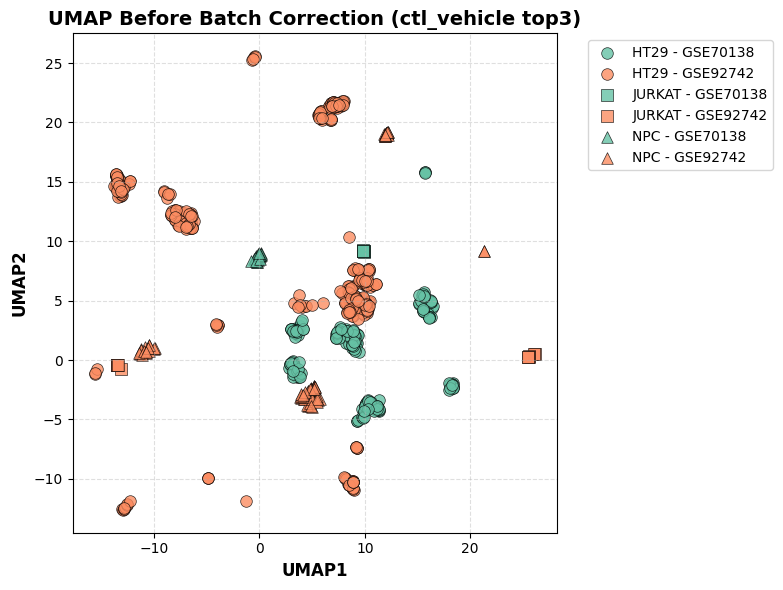

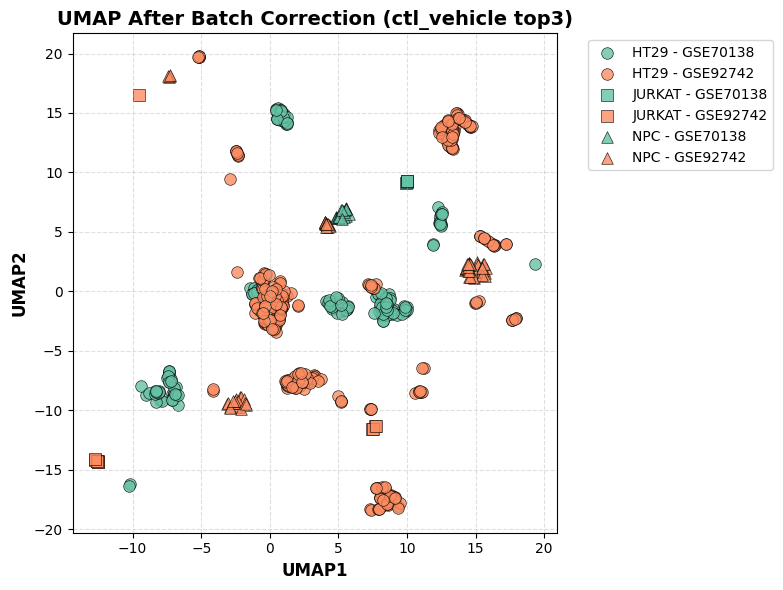

In [29]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Step 1: Identify shared cell lines
# -----------------------------
celllines_dataset1 = adata_subset_before.obs.loc[
    adata_subset_before.obs['dataset_name'] == 'GSE70138', 'cell_id'
].unique()
celllines_dataset2 = adata_subset_before.obs.loc[
    adata_subset_before.obs['dataset_name'] == 'GSE92742', 'cell_id'
].unique()

shared_celllines = np.intersect1d(celllines_dataset1, celllines_dataset2)
print("Shared cell lines:", shared_celllines)

# -----------------------------
# Step 2: Filter ctl_vehicle controls
# -----------------------------
adata_before_ctl = adata_subset_before[
    (adata_subset_before.obs['cell_id'].isin(shared_celllines)) &
    (adata_subset_before.obs['pert_type'] == 'ctl_vehicle')
].copy()

adata_after_ctl = adata_subset_after[
    (adata_subset_after.obs['cell_id'].isin(shared_celllines)) &
    (adata_subset_after.obs['pert_type'] == 'ctl_vehicle')
].copy()

# -----------------------------
# Step 3: Compute mean per cell line
# -----------------------------
def mean_per_cellline(adata):
    means = {}
    for cell in adata.obs['cell_id'].unique():
        subset = adata[adata.obs['cell_id'] == cell]
        # convert sparse matrix if needed
        means[cell] = subset.X.mean(axis=0).A1 if hasattr(subset.X, "A1") else subset.X.mean(axis=0)
    return pd.DataFrame(means)

mean_before = mean_per_cellline(adata_before_ctl)
mean_after  = mean_per_cellline(adata_after_ctl)

# -----------------------------
# Step 4: Compute mean difference per cell line
# -----------------------------
# Take mean across genes
mean_before_avg = mean_before.mean(axis=0)
mean_after_avg  = mean_after.mean(axis=0)
mean_diff = mean_after_avg - mean_before_avg

# Sort and select top 3 most changed controls
top3_ctl = mean_diff.sort_values(ascending=False).head(3).index.tolist()
print("Top 3 ctl_vehicle cell lines by mean diff:", top3_ctl)

# -----------------------------
# Step 5: Prepare DataFrames for plotting UMAP
# -----------------------------
def prepare_df(adata, umap=True):
    # Keep only top3 ctl_vehicle cell lines
    mask = adata.obs['cell_id'].isin(top3_ctl)
    df = adata.obs[mask].copy()
    
    if umap:
        df['x'] = adata.obsm['X_umap'][mask, 0]
        df['y'] = adata.obsm['X_umap'][mask, 1]
    else:
        df['x'] = adata.obsm['X_pca'][mask, 0]
        df['y'] = adata.obsm['X_pca'][mask, 1]
    
    return df

df_before = prepare_df(adata_before_ctl, umap=True)
df_after  = prepare_df(adata_after_ctl, umap=True)

# -----------------------------
# Step 6: Plotting function
# -----------------------------
def scatter_shared(df, title="UMAP Scatter", savefile=None):
    cell_lines = sorted(df['cell_id'].unique())
    datasets = sorted(df['dataset_name'].unique())
    
    markers = ['o','s','^']  # one per cell line
    marker_dict = dict(zip(cell_lines, markers))
    
    palette = sns.color_palette("Set2", n_colors=len(datasets))
    color_dict = dict(zip(datasets, palette))
    
    plt.figure(figsize=(8,6))
    
    for cell_line in cell_lines:
        df_sub = df[df['cell_id']==cell_line]
        for dataset in datasets:
            df_sub2 = df_sub[df_sub['dataset_name']==dataset]
            plt.scatter(
                df_sub2['x'],
                df_sub2['y'],
                s=70,
                alpha=0.8,
                marker=marker_dict[cell_line],
                color=color_dict[dataset],
                edgecolor='k',
                linewidth=0.5,
                label=f'{cell_line} - {dataset}'
            )
    
    plt.xlabel('UMAP1', fontsize=12, weight='bold')
    plt.ylabel('UMAP2', fontsize=12, weight='bold')
    plt.title(title, fontsize=14, weight='bold')
    plt.grid(True, linestyle='--', alpha=0.4)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05,1), loc='upper left', fontsize=10)
    
    plt.tight_layout()
    if savefile:
        plt.savefig(savefile, dpi=300, bbox_inches='tight')
    plt.show()

# -----------------------------
# Step 7: Plot UMAP before and after batch correction
# -----------------------------
scatter_shared(df_before, title="UMAP Before Batch Correction (ctl_vehicle top3)", savefile="UMAP_before_ctl_top3.png")
scatter_shared(df_after, title="UMAP After Batch Correction (ctl_vehicle top3)", savefile="UMAP_after_ctl_top3.png")